[*********************100%***********************]  1 of 1 completed


Historical daily returns : 0.001
Historical daily volatility : 0.020
Current AAPL price : $271.12
Mean simulated price after 1 year : $271.46
Median simulated price after 1 year : $271.38
Minimum simulated price : $252.50
Maximum simulated price : $291.83
5th percentile : $262.50
95th percentile : $280.52


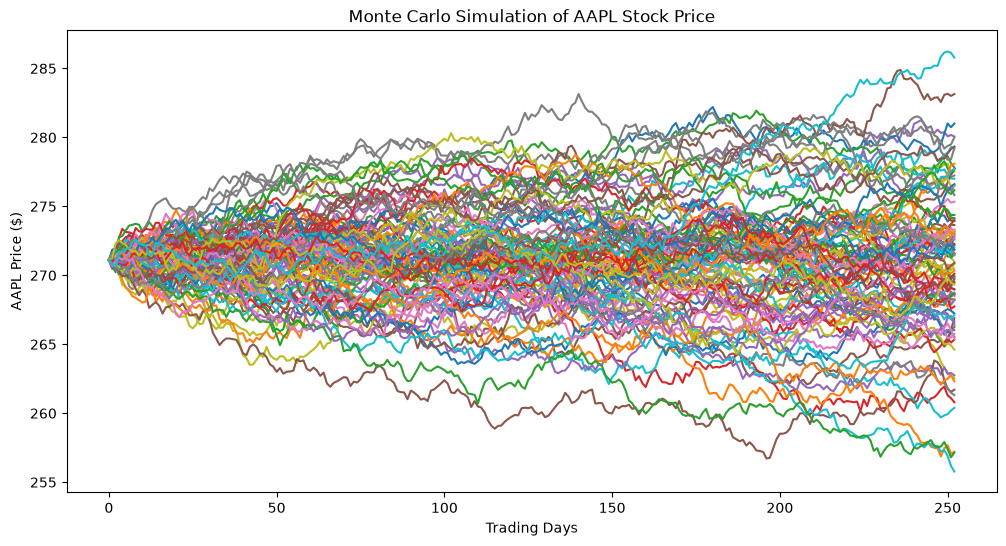

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

data = yf.download("AAPL", start="2020-01-01", end="2026-01-01", auto_adjust=True) 
closing_prices = data["Close"]["AAPL"]  
returns = closing_prices.pct_change().dropna()
mu = returns.mean()
sigma = returns.std()

print(f"Historical daily returns : {mu:.3f}")
print(f"Historical daily volatility : {sigma:.3f}")

T = 1.0 
S0 = closing_prices.iloc[-1]
n_steps = 252
n_simulations = 10000
dt = T / n_steps

rng = np.random.default_rng(42)

price = np.zeros((n_steps + 1, n_simulations))
price[0] = S0

for t in range(n_steps):
    z  = rng.standard_normal(n_simulations)

    price[t + 1] = price[t] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * z * np.sqrt(dt))   

final_price = price[n_steps] 

print(f"Current AAPL price : ${S0:.2f}")
print(f"Mean simulated price after 1 year : ${np.mean(final_price):.2f}")
print(f"Median simulated price after 1 year : ${np.median(final_price):.2f}")
print(f"Minimum simulated price : ${np.min(final_price):.2f}")
print(f"Maximum simulated price : ${np.max(final_price):.2f}")
print(f"5th percentile : ${np.percentile(final_price, 5):.2f}")
print(f"95th percentile : ${np.percentile(final_price, 95):.2f}")

plt.figure(figsize=(12,6))
plt.plot(price[:, :100])
plt.title("Monte Carlo Simulation of AAPL Stock Price")
plt.xlabel("Trading Days")
plt.ylabel("AAPL Price ($)")
plt.show()